In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Import important libraries:**

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

**Load the data**

In [ ]:
df_copy = pd.read_csv('/content/drive/MyDrive/GL_AIML/EssembleTechnique/ProjectWork/EasyVisa.csv')



In [ ]:
df_copy.head(5)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
df_copy.columns

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [ ]:
df_copy.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


As per the result , we can see that dataset is well-structured and doesn’t have any missing values

**Exploratory Data Analysis**

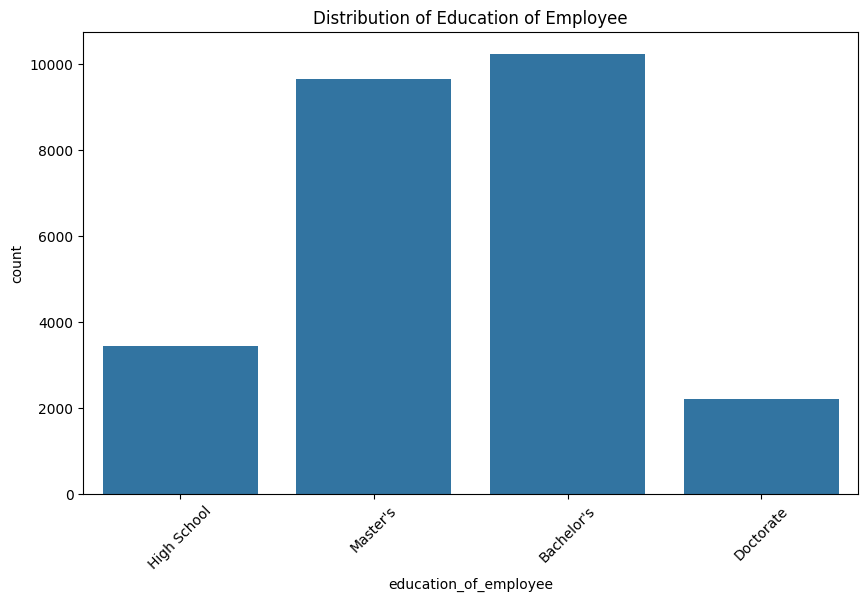

In [ ]:
#Univariate Analysis

##Distribution of education_of_employee

plt.figure(figsize=(10, 6))
plt.title('Distribution of Education of Employee')
sns.countplot(data=df_copy, x='education_of_employee')
plt.xticks(rotation=45)
plt.show()



From above analysis we can say that highest no of employees are having Bachelor's degree followed by Master's and very less no of employees are having Doctorate Degree.

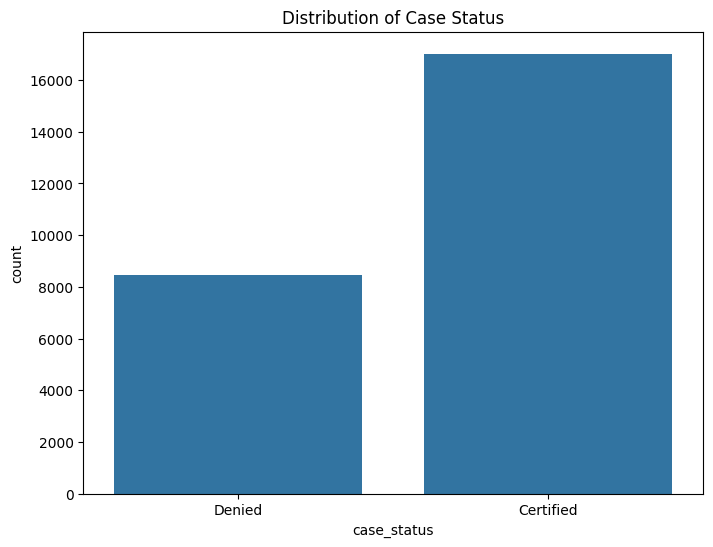

In [ ]:
#Distribution of Case Status

plt.figure(figsize=(8, 6))
plt.title('Distribution of Case Status')
sns.countplot(data=df_copy, x='case_status')
plt.show()

From above analysis we can say that , Visa was certified to more that 16000 applications and denied to almost 8000 applications

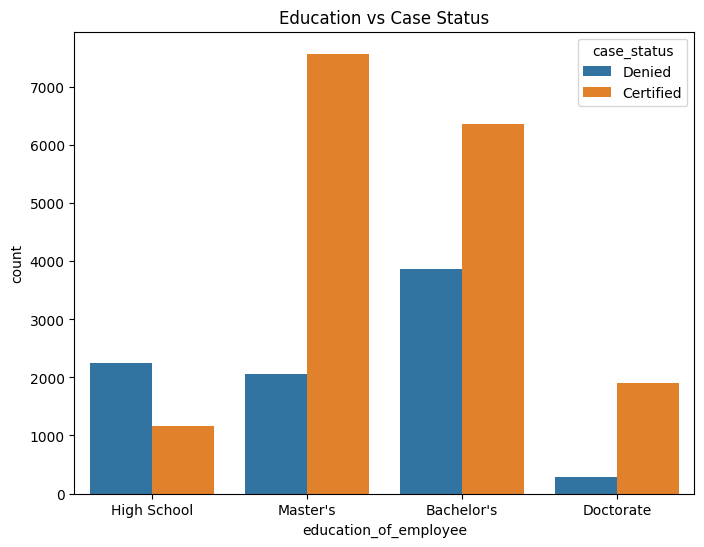

In [ ]:
#Bivariate Analysis

##Education VS Case Status

plt.figure(figsize=(8,6))
plt.title('Education vs Case Status')
sns.countplot(data=df_copy, x='education_of_employee' , hue='case_status')
plt.show()

So, from above analysis its clear that the half of the visa application are getting denied mostly if education of the employee is below than Bachelors.

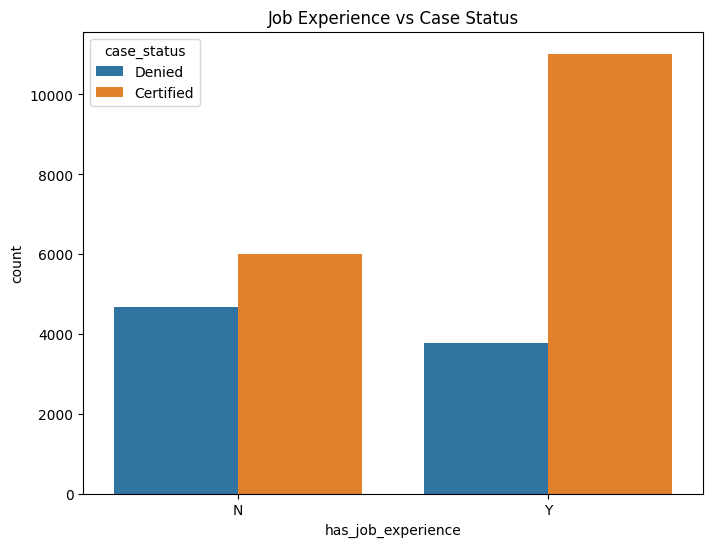

In [ ]:
##Job Experience vs Case Status

plt.figure(figsize=(8,6))
plt.title('Job Experience vs Case Status')
sns.countplot(data=df_copy, x='has_job_experience', hue='case_status')
plt.show()


From the above analysis between Job Exp and Case Status, we can see that having a job experience is plus point for getting visa .

**EDA QUESTIONS**

# **1. Those with higher education may want to travel abroad for a well-paid job. Does education play a role in Visa certification?**

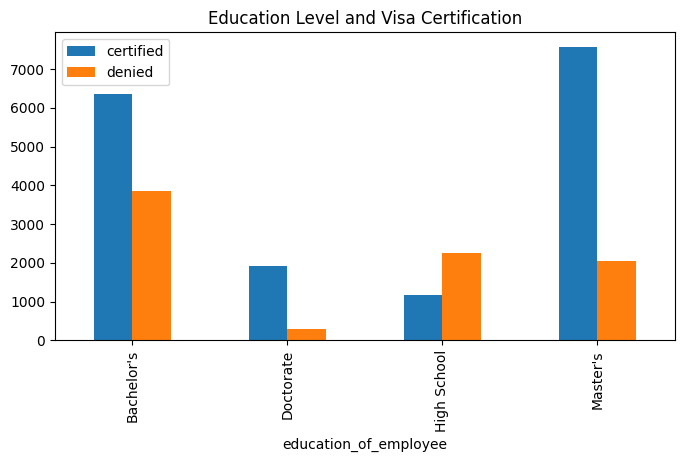

In [ ]:
##Education and Visa Certification
education_certified = df_copy[df_copy['case_status'] == 'Certified']['education_of_employee'].value_counts()
education_denied = df_copy[df_copy['case_status'] == 'Denied']['education_of_employee'].value_counts()
df_copy_education = pd.DataFrame({'certified': education_certified, 'denied': education_denied})
df_copy_education.plot(kind='bar', figsize=(8, 4))
plt.title('Education Level and Visa Certification')
plt.show()

As per Bivariate analysis and above analysis it is clear that education plays important role in Visa Certification and also to get well paid jobs.

# **2. How does the visa status vary across different continents?**

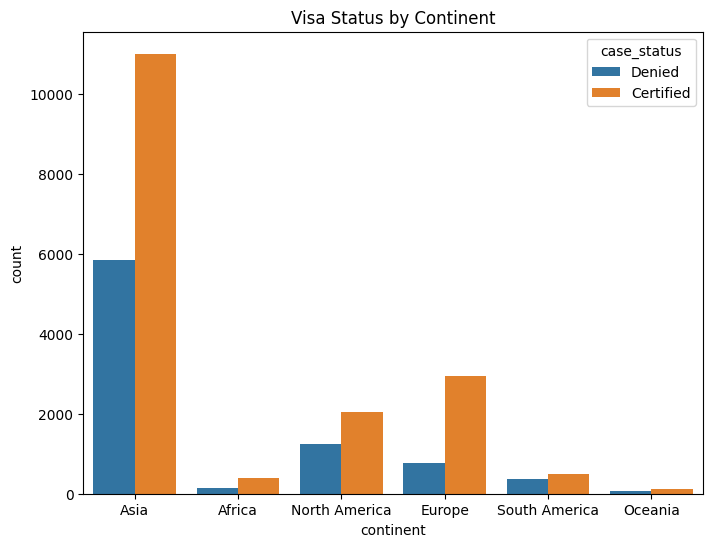

In [ ]:
##Visa status by Various Continents

plt.figure(figsize=(8, 6))
plt.title('Visa Status by Continent')
sns.countplot(data=df_copy, x='continent', hue='case_status')
plt.show()


From above analysis, we can say that most of the Visa applications are coming from Asia countries. Also most certified and denied applications are also from Asia.

Least Visa applications being applied from Oceania countries.

Ratio of certified and denied applications are lowest from Europian countries.

# **3. Experienced professionals might look abroad for opportunities to improve their lifestyles and career development. Does work experience influence visa status?**

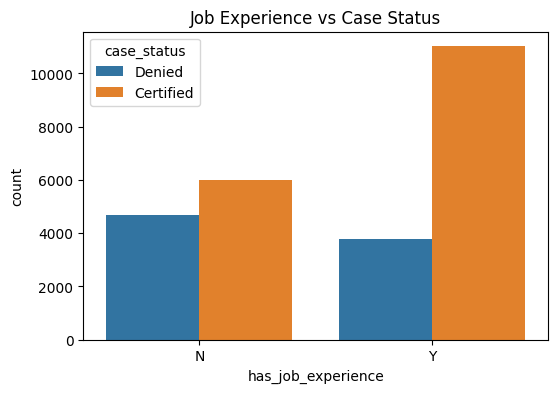

In [ ]:
##Job Experience vs Case Status

plt.figure(figsize=(6,4))
plt.title('Job Experience vs Case Status')
sns.countplot(data=df_copy, x='has_job_experience', hue='case_status')
plt.show()

As per the analysis, Experienced professionals have good oppertunities to improve their lifestyle and career as work experience influence Visa Status.

# **4. In the United States, employees are paid at different intervals. Which pay unit is most likely to be certified for a visa?**

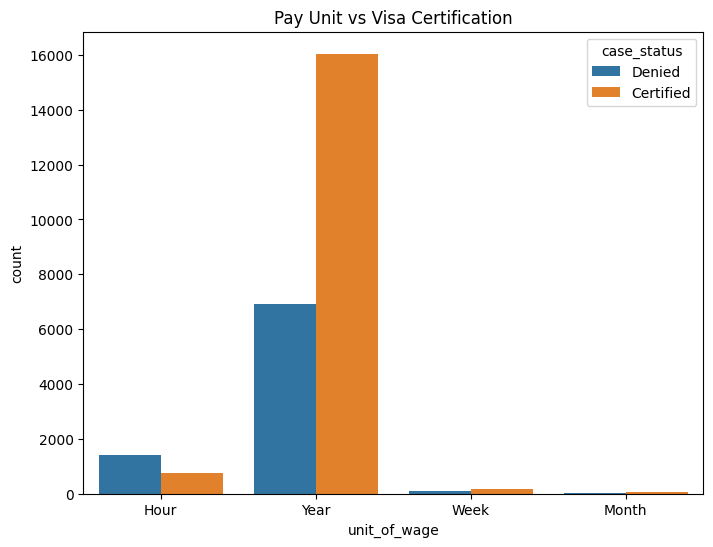

In [ ]:
##Pay Unit VS Visa Certification

plt.figure(figsize=(8, 6))
plt.title('Pay Unit vs Visa Certification')
sns.countplot(data=df_copy, x='unit_of_wage', hue='case_status')
plt.show()

As per the analysis it is clear that **Yearly pay unit** is most likely to be certified for a visa

# **5. The US government has established a prevailing wage to protect local talent and foreign workers. How does the visa status change with the prevailing wage?**

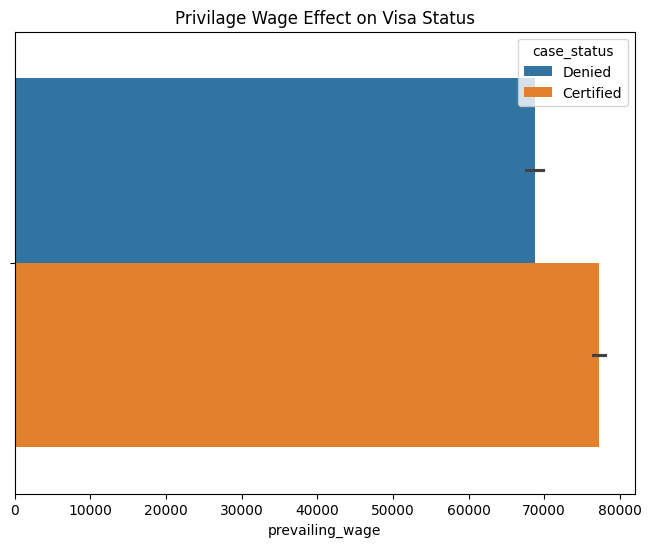

In [ ]:
## Privilage Wage Effect

plt.figure(figsize=(8, 6))
plt.title('Privilage Wage Effect on Visa Status')
sns.barplot(data=df_copy, x='prevailing_wage', hue='case_status')
plt.show()

As per analysis , we can say that there have been an impact on the visa approval because of prevailing wage to protect local talent. Out of total Visa applications approx 46% of visa getting deined and only 54% are getting certificate.


## **Data Preprocessing**

**Missing Value Treatment**

Lets check missing values

In [ ]:
#check for missing values
missing_values = df_copy.isnull().sum()
print(missing_values)

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64


So, as per the result we dont have any missing value here so no tyreatment needed.

**Outlier Detection and Treatment**

Outliers can distort the result of our analysis and models, hence , detecting and treating them is important.

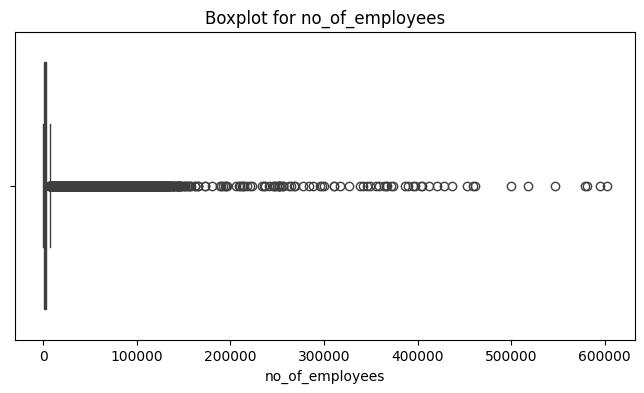

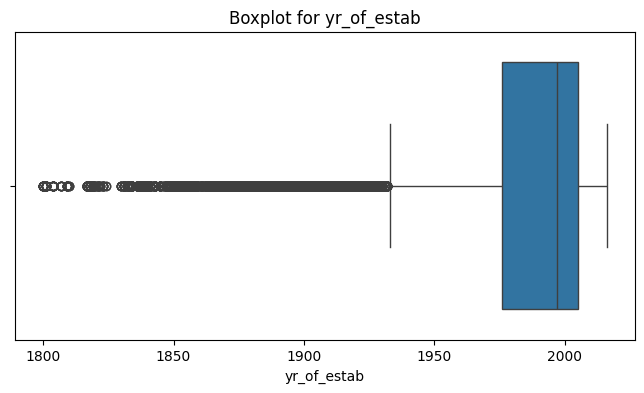

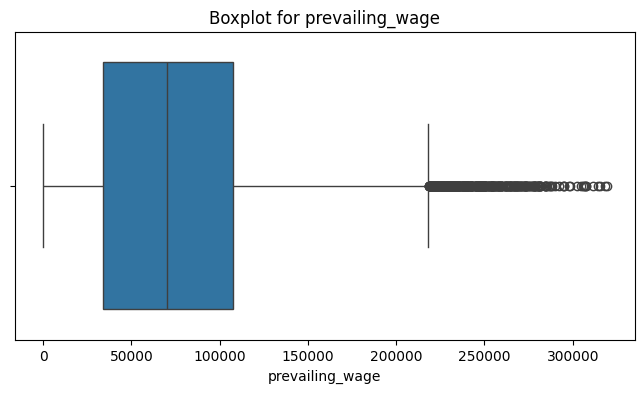

In [ ]:
#Boxlot plotting to detect outliers for numerical columns

num_cols = ['no_of_employees', 'yr_of_estab', 'prevailing_wage']
for col in num_cols:
    plt.figure(figsize=(8, 4))
    plt.title(f'Boxplot for {col}')
    sns.boxplot(data=df_copy, x=col)
    plt.show()




**Interpretation of box plot**

No of employees: its showing significant no of outliers, few data points far exceeding the typical range.

yr_of_estab: showing some older establishment years and that we can consider outliers.

prevailing_wage: Shows values with few extreme values beyond the range.


*We can handle these outliers by filtering out the extreme values.*

In [ ]:
#Handeling Outliers

# Handling Outliers by filtering extreme values for prevailing wage
lower_bound_wage = df_copy['prevailing_wage'].quantile(0.01)
upper_bound_wage = df_copy['prevailing_wage'].quantile(0.99)

filtered_df_copy = df_copy[(df_copy['prevailing_wage'] >= lower_bound_wage) & (df_copy['prevailing_wage'] <= upper_bound_wage)]


# Handling Outliers by filtering extreme values for no_of_employees
lower_bound_employees = df_copy['no_of_employees'].quantile(0.01)
upper_bound_employees = df_copy['no_of_employees'].quantile(0.99)

filtered_df_copy = filtered_df_copy[(filtered_df_copy['no_of_employees'] >= lower_bound_employees) & (filtered_df_copy['no_of_employees'] <= upper_bound_employees)]

# Handling Outliers by filtering extreme values for yr_of_estab
lower_bound_estab = df_copy['yr_of_estab'].quantile(0.01)
upper_bound_estab = df_copy['yr_of_estab'].quantile(0.99)

filtered_df_copy = filtered_df_copy[(filtered_df_copy['yr_of_estab'] >= lower_bound_estab) & (filtered_df_copy['yr_of_estab'] <= upper_bound_estab)]

Above code filters out the extreme values, outliers, in all three columns to reduce their impact on subsequent analysis.

**Feature Engineering**

Feature engineering code will help the model capturing underline pattern better.

1. Handling Categorical variable - ML generally requires numerical input, so categorical values need to be encoded.

In [ ]:
## Encoding Categorical Variables
le = LabelEncoder()
df_copy['education_of_employee'] = le.fit_transform(df_copy['education_of_employee'])
df_copy['has_job_experience'] = le.fit_transform(df_copy['has_job_experience'])
df_copy['requires_job_training'] = le.fit_transform(df_copy['requires_job_training'])
df_copy['full_time_position'] = le.fit_transform(df_copy['full_time_position'])
df_copy['continent'] = le.fit_transform(df_copy['continent'])
df_copy['region_of_employment'] = le.fit_transform(df_copy['region_of_employment'])
df_copy['unit_of_wage'] = le.fit_transform(df_copy['unit_of_wage'])
df_copy['case_status'] = le.fit_transform(df_copy['case_status'])


In [ ]:
# Before making any changes , I am creating a copy of the data set

#df_copy = df.copy()

**Train-test split**

In [ ]:
#Train-Test Split

X = df_copy.drop(['case_status', 'case_id'], axis=1)
y = df_copy['case_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

le = LabelEncoder()
y = le.fit_transform(y) #Converting 'Certified' and 'Denied' to 0 and 1

Dropping case_status: it is the target variable and if we include this column in this feature and it could lead to data leakage.

Dropping case_id: its an unique identifier for each record in the dataset. It does not provide any predictive power for the model because its just a unique value and has no relationship with the target variable.

# **Model Building - Bagging**

1. Choose the metric to optimize for the problem: For classification problems like this we generally choose the Metric like accuracy, precision, recall, F1-score, and AUC-ROC.

2. Model Building: Decision Tree, Bagging, Random Forest.


3. Model Performance Evaluation: We will Evaluate models using accuracy, precision, recall, F1-score, and AUC-ROC.

In [ ]:
#Decision Tree Model

#Building and Model Evaluation

dt_model =  DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

#Prediction

y_pred_dt = dt_model.predict(X_test)


#Evaluation

print("Decision Tree Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt)}")
print(f"Pricision: {precision_score(y_test, y_pred_dt, pos_label=1)}")
print(f"Recall: {recall_score(y_test, y_pred_dt, pos_label=1)}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt, pos_label=1)}")
print(f"AUC-ROC: {roc_auc_score(y_test, dt_model.predict_proba(X_test)[:, 1])}")
print(classification_report(y_test, y_pred_dt))




Decision Tree Performance:
Accuracy: 0.6661433804290947
Pricision: 0.49471210340775557
Recall: 0.5001980198019802
F1-Score: 0.4974399369830642
AUC-ROC: 0.6240978377970635
              precision    recall  f1-score   support

           0       0.75      0.75      0.75      5119
           1       0.49      0.50      0.50      2525

    accuracy                           0.67      7644
   macro avg       0.62      0.62      0.62      7644
weighted avg       0.67      0.67      0.67      7644



Analysis on Decision Tree Model's Performance:

Accuracy - 67% - 67% of the cases were classified correctly, there are some improvement required

AUC-ROC: 0.62 - AUC-ROC value should be closer to 1, improvement required

Imbalanced Classes: We can see there are more instances of class 0 than class 1. This can often lead to models being biased towards the majority class.

In [ ]:
#Bagging Model

bagging_model = BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bagging_model.fit(X_train, y_train)

#Prediction

y_pred_bagging = bagging_model.predict(X_test)


#Evaluation

print("Bagging Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_bagging)}")
print(f"Pricision: {precision_score(y_test, y_pred_bagging, pos_label=1)}")
print(f"Recall: {recall_score(y_test, y_pred_bagging, pos_label=1)}")
print(f"F1-Score: {f1_score(y_test, y_pred_bagging, pos_label=1)}")
print(f"AUC-ROC: {roc_auc_score(y_test, bagging_model.predict_proba(X_test)[:, 1])}")
print(classification_report(y_test, y_pred_bagging))



/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


Bagging Performance:
Accuracy: 0.7209576138147566
Pricision: 0.5982948846539619
Recall: 0.47247524752475245
F1-Score: 0.5279929187873424
AUC-ROC: 0.745044998346289
              precision    recall  f1-score   support

           0       0.76      0.84      0.80      5119
           1       0.60      0.47      0.53      2525

    accuracy                           0.72      7644
   macro avg       0.68      0.66      0.66      7644
weighted avg       0.71      0.72      0.71      7644



Analysis of Bagging Model:

Accuracy : 72% - We can see improvement over the Decision tree's model 67%

AUC-ROC : 0.745 - Again better than decision tree 0.62

bagging model vs decision tree: bagging model is clearly better in overall accuracy and ability to correctly identify the majority class, class 0. Certified class ahs also improved siginificantly.

In [ ]:
#Random Forest Model

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

#Prediction

y_pred_rf = rf_model.predict(X_test)

#Evaluation

print("Random Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")
print(f"Pricision: {precision_score(y_test, y_pred_rf, pos_label=1)}")
print(f"Recall: {recall_score(y_test, y_pred_rf, pos_label=1)}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf, pos_label=1)}")
print(f"AUC-ROC: {roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])}")
print(classification_report(y_test, y_pred_rf))


Random Forest Performance:
Accuracy: 0.7272370486656201
Pricision: 0.6114488348530902
Recall: 0.478019801980198
F1-Score: 0.5365636808179595
AUC-ROC: 0.7519398706817352
              precision    recall  f1-score   support

           0       0.77      0.85      0.81      5119
           1       0.61      0.48      0.54      2525

    accuracy                           0.73      7644
   macro avg       0.69      0.66      0.67      7644
weighted avg       0.72      0.73      0.72      7644



Random forest analysis:

Accuracy: 73% - Slightly improvement over the Bagging Model(72%).

AUC-ROC: 0.752 - again slighly better than bagging model (0.745)

F1 Score - Class 0 - 81%, better than decision tree (80%)

F1 Score - 54% - Very small improvement over bagging model

Random Forest VS Bagging : The Random forest shows a small improvement in overtall accuracy. However, the for class1 remains very similar.

**About Decision Tree, Bagging, Random Forest:**

Decision Tree: it provides a simple and interpretable model but may overfit the data, leading to lower generalization performance.

Bagging: it reduces overfitting compared to a single decision tree by averaging multiple trees' predictions, often leading to improved performance.

Random Forest: it further enhances performance by introducing more randomness during training, making it one of the most robust models for classification tasks.

# **Model Improvement - Bagging**

**1. Decision Tree Tuning**

In [ ]:
#Define the Parameter grid for decision Tree

parameter_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

#GridSearchCv for Decision Tree

grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), parameter_grid_dt, cv=5, scoring='f1_macro')
grid_search_dt.fit(X_train, y_train)

#Print best parameters and scores

print("Best Parameters for Decision Tree:")
print(grid_search_dt.best_params_)
print("Best Score for Decision Tree:" , grid_search_dt.best_score_)

#Gettinng best decision tree model

best_dt_model = grid_search_dt.best_estimator_

#Evaluation of best Decision Tree Model

y_pred_best_dt = best_dt_model.predict(X_test)
print("Tuned Decision Tree Performance: ")
print(classification_report(y_test, y_pred_best_dt))


Best Parameters for Decision Tree:
{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best Score for Decision Tree: 0.6715750909504019
Tuned Decision Tree Performance: 
              precision    recall  f1-score   support

           0       0.81      0.72      0.76      5119
           1       0.54      0.65      0.59      2525

    accuracy                           0.70      7644
   macro avg       0.67      0.69      0.68      7644
weighted avg       0.72      0.70      0.71      7644



**Analysis:**

Best Parameters: 'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5'

Accuracy: 0.70, Precision: 0.54, Recall: 0.65, F1-Score: 0.59.

Tuned Decision Tree Model has improved its performance, Accuracy has increased, we can see significant improvement in Recall as well. It means its capturing more positive cases. Precision has decreased slighly but the overall F1-Score has improved.

**2. Bagging Tuning**

In [ ]:
#Define the Parameter grid for Bagging

#parameter_grid_dt = {
 #   'criterion': ['gini', 'entropy'],
  #  'max_depth': [None, 10, 20, 30],
   # 'min_samples_split': [2, 5, 10],
    #'min_samples_leaf': [1, 2, 4],
    #'class_weight': [None, 'balanced']
#}

parameter_grid_bagging = {
    'n_estimators': [50, 100, 200],
    'max_samples': [0.5, 0.7, 1.0],
    'base_estimator__max_depth': [None, 5, 10],  # Tuning base Decision Tree
    'base_estimator__min_samples_split': [2, 5],
    'base_estimator__class_weight': [None, 'balanced'] # Move class_weight to base estimator
}

#Create a base Decision Tree for bagging

base_dt = DecisionTreeClassifier(random_state=42)

#GridSearchCv for bagging

grid_search_bagging = GridSearchCV(BaggingClassifier(base_estimator=base_dt, random_state=42), parameter_grid_bagging, cv=5, scoring='f1_macro')
grid_search_bagging.fit(X_train, y_train)

#Print best parameters and scores

print("Best Parameters for Bagging:")
print(grid_search_bagging.best_params_)
print("Best Score for Bagging:" , grid_search_bagging.best_score_)

#Gettinng best decision tree model

best_bagging_model = grid_search_bagging.best_estimator_

#Evaluation of best Bagging Model

y_pred_best_bagging = best_bagging_model.predict(X_test)
print("Tuned Bagging Performance: ")
print(classification_report(y_test, y_pred_best_bagging))

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/en

Best Parameters for Bagging:
{'base_estimator__class_weight': 'balanced', 'base_estimator__max_depth': 10, 'base_estimator__min_samples_split': 5, 'max_samples': 0.7, 'n_estimators': 200}
Best Score for Bagging: 0.6994185042198051
Tuned Bagging Performance: 
              precision    recall  f1-score   support

           0       0.80      0.78      0.79      5119
           1       0.58      0.61      0.60      2525

    accuracy                           0.73      7644
   macro avg       0.69      0.70      0.70      7644
weighted avg       0.73      0.73      0.73      7644



**Analysis:**

base_estimator__class_weight: balanced

base_estimator__max_depth: 10

base_estimator__min_samples_split: 5

max_samples: 0.7

n_estimators: 200

Accuracy: 0.73

Precision: 0.58

Recall: 0.61

F1-Score: 0.60

Tuned Bagging Model hs also improved its performance, Accuracy increased and F1-Score has improved. The model is performing well.

**3. Random Forest Tuning**

In [ ]:
#Define the parameter grid for Random Forest

parameter_grid_rf = {
    'n_estimators' : [50, 100, 200],
    'max_depth' : [None, 5, 10, 20],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'class_weight' : [None, 'balanced']

}

#GridSearchCV for Random Forest

grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), parameter_grid_rf, cv=5, scoring='f1_macro')
grid_search_rf.fit(X_train, y_train)

#Print best parameters and best score

print("Best parameters for Random Forest:")
print(grid_search_rf.best_params_)
print("Best F1-Macro Score for Random Forest:", grid_search_rf)

#Gettinng best Random Forest model

best_rf_model = grid_search_rf.best_estimator_

#Evaluation of best Random Forest Model

y_pred_best_rf = best_rf_model.predict(X_test)
print("Tuned RF Performance: ")
print(classification_report(y_test, y_pred_best_rf))

Best parameters for Random Forest:
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}
Best F1-Macro Score for Random Forest: GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'class_weight': [None, 'balanced'],
                         'max_depth': [None, 5, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='f1_macro')
Tuned RF Performance: 
              precision    recall  f1-score   support

           0       0.81      0.76      0.79      5119
           1       0.57      0.64      0.60      2525

    accuracy                           0.72      7644
   macro avg       0.69      0.70      0.69      7644
weighted avg       0.73      0.72      0.73      7644



**Analysis:**

class_weight: 'balanced

max_depth: 10

min_samples_leaf: 4

min_samples_split: 2

n_estimators: 50

Accuracy: 0.72

Precision: 0.57

Recall: 0.64

F1-Score: 0.60

As per teh result, we can say that this model provides a good balance between Precision and Recall bor both Classes.
The overall accuracy of 0.72 and macro-average F1-Score of 0.69 shows a good level of performance.

# **Model Building - Boosting**

**1. AdaBoost**

In [ ]:
#AdaBoost Model

adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)
adaboost_model.fit(X_train, y_train)

#Predictions

y_pred_ada = adaboost_model.predict(X_test)

#Evaluation

print("Adaboost Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ada)}")
print(f"Pricision: {precision_score(y_test, y_pred_ada, pos_label=1)}")
print(f"Recall: {recall_score(y_test, y_pred_ada, pos_label=1)}")
print(f"F1-Score: {f1_score(y_test, y_pred_ada, pos_label=1)}")
print(f"AUC-ROC: {roc_auc_score(y_test, adaboost_model.predict_proba(X_test)[:, 1])}")
print(classification_report(y_test, y_pred_ada))


Adaboost Performance:
Accuracy: 0.7373103087388801
Pricision: 0.6620689655172414
Recall: 0.4182178217821782
F1-Score: 0.512621359223301
AUC-ROC: 0.7684003489233471
              precision    recall  f1-score   support

           0       0.76      0.89      0.82      5119
           1       0.66      0.42      0.51      2525

    accuracy                           0.74      7644
   macro avg       0.71      0.66      0.67      7644
weighted avg       0.73      0.74      0.72      7644



**Analysis:**

Accuracy: 0.7373103087388801

Pricision: 0.6620689655172414

Recall: 0.4182178217821782

F1-Score: 0.512621359223301

AUC-ROC: 0.7684003489233471

Adaboost has a slightly better better accuracy (0.74) compared to Random Forest (0.72).

Random Forest has a slightly better macro F1-score (0.69) than AdaBoost (0.67). This suggests that Random Forest might be doing a better job overall at balancing precision and recall for both classes.

**2. Gradient Boosting**

In [ ]:
#Gradient Boosting Model

gradientboost_model = GradientBoostingClassifier(n_estimators = 100, random_state = 42)
gradientboost_model.fit(X_train, y_train)

#Predictions

y_pred_gboosting = gradientboost_model.predict(X_test)

#Evaluation

print("Gradient Boosting Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gboosting)}")
print(f"Pricision: {precision_score(y_test, y_pred_gboosting, pos_label=1)}")
print(f"Recall: {recall_score(y_test, y_pred_gboosting, pos_label=1)}")
print(f"F1-Score: {f1_score(y_test, y_pred_gboosting, pos_label=1)}")
print(f"AUC-ROC: {roc_auc_score(y_test, gradientboost_model.predict_proba(X_test)[:, 1])}")
print(classification_report(y_test, y_pred_gboosting))


Gradient Boosting Performance:
Accuracy: 0.7443746729461015
Pricision: 0.6606640405177265
Recall: 0.464950495049505
F1-Score: 0.5457926545792654
AUC-ROC: 0.7796459704575653
              precision    recall  f1-score   support

           0       0.77      0.88      0.82      5119
           1       0.66      0.46      0.55      2525

    accuracy                           0.74      7644
   macro avg       0.72      0.67      0.68      7644
weighted avg       0.73      0.74      0.73      7644



**Analysis:**

Accuracy: 0.7443746729461015

Pricision: 0.6606640405177265

Recall: 0.464950495049505

F1-Score: 0.5457926545792654

AUC-ROC: 0.7796459704575653

AdaBoost and Gradient Boosting have similar performance for class 0, with high precision and recall, leading to good F1-scores.

AUC-ROC has been improved for Gradient Boosting here, which indicates better discriminatory power

# **Model Improvement - Boosting**

**1. Adaboost Tuning**

In [ ]:
#Adaboostng Parameters

para_grid_adaboost = {
    'n_estimators' : [50, 100, 200],
    'learning_rate': [0.1, 0.5, 1.0],
    'algorithm' : ['SAMME', 'SAMME.R']
}

#GridSearchCV for Adaboost

grid_search_adaboost = GridSearchCV(AdaBoostClassifier(random_state=42), para_grid_adaboost, cv=5, scoring = 'f1_macro')
grid_search_adaboost.fit(X_train, y_train)

#Print best Parameters and Scores

print("Best Parameters for AdaBoost:")
print(grid_search_adaboost.best_params_)
print("Best Score for AdaBoost:", grid_search_adaboost.best_score_)

#Getting best Adaboost Model

best_adaboost_model = grid_search_adaboost.best_estimator_

#Evaluation of Best Adaboost Model

y_pred_best_adaboost = best_adaboost_model.predict(X_test)
print("Tuned AdaBoost Performance:")
print(classification_report(y_test, y_pred_best_adaboost))


Best Parameters for AdaBoost:
{'algorithm': 'SAMME.R', 'learning_rate': 1.0, 'n_estimators': 200}
Best Score for AdaBoost: 0.666707966099691
Tuned AdaBoost Performance:
              precision    recall  f1-score   support

           0       0.75      0.89      0.82      5119
           1       0.65      0.41      0.51      2525

    accuracy                           0.73      7644
   macro avg       0.70      0.65      0.66      7644
weighted avg       0.72      0.73      0.71      7644



**Analysis:**

Best Parameters: {'algorithm': 'SAMME.R', 'learning_rate': 1.0, 'n_estimators': 200}

Accuracy: 0.73

Macro avg F1-score: 0.66

Weighted avg F1-score: 0.71

Precision: 0.75 for class 0, 0.65 for class 1

Recall: 0.89 for class 0, 0.41 for class 1

F1-score: 0.82 for class 0, 0.51 for class 1

Accuracy wise , Adaboost lowers in accuracy in comparison with Gradient Boosting

Gradient Boosting has a better macro F1-score (0.68) than AdaBoost (0.66), indicating a better balance between precision and recall for both classes.

AdaBoost has slightly higher recall for class 0 (0.89) compared to Gradient Boosting (0.88). However, this difference is very small and might not be practically significant.

We need to do more tuning to get better results.

**2. Gradient Boosting Tuning**

In [ ]:
#Parameter Grid for Gradient Boosting

param_grid_gdboost = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.1, 0.5, 1.0],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

#Grid Search for Gradient boosting

grid_search_gdboost = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gdboost, cv=5, scoring='f1_macro')
grid_search_gdboost.fit(X_train, y_train)

#Best Parameters and Scores

print("Best Parameters for Gradient Boosting:")
print(grid_search_gdboost.best_params_)
print("Best Score for Gradient Boosting:", grid_search_gdboost.best_score_)

#Best Gradient Boosting model

best_gdboost_model = grid_search_gdboost.best_estimator_

#Evaluation of best Gradient Boosting Model

y_pred_best_gdboost = best_gdboost_model.predict(X_test)
print("Gradient Boosting Performance - Tuned:")
print(classification_report(y_test, y_pred_best_gdboost))


Best Parameters for Gradient Boosting:
{'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}
Best Score for Gradient Boosting: 0.6965498131665996
Gradient Boosting Performance - Tuned:
              precision    recall  f1-score   support

           0       0.78      0.88      0.82      5119
           1       0.66      0.49      0.56      2525

    accuracy                           0.75      7644
   macro avg       0.72      0.68      0.69      7644
weighted avg       0.74      0.75      0.74      7644



**Analysis:**

Accuracy: 0.75

Macro avg F1-score: 0.69

Weighted avg F1-score: 0.74

Precision: 0.78 for class 0, 0.66 for class 1

Recall: 0.88 for class 0, 0.49 for class 1

F1-score: 0.82 for class 0, 0.56 for class 1


The tuned Gradient Boosting model prove top be supirior in performance compared to the other models. It has higher accuracy, a better macro F1-score, and a better weighted average F1-score.

Tuned Gradient Boosting model appears to be the better performer overall in comparison of every other models

# **Actionable Insights & Recommendations**

**Insights:**

**Analysis of performnace of the models:**

***Decision Tree:***
- Baseline model with the lowest performance metrics.
- Tuned version shows improvement in recall and F1-score.

***Bagging:***
- Provides a noticeable improvement over the Decision Tree.
- Shows a balanced performance with a good AUC-ROC score.
- Tuned version has slightly better precision, recall, and F1-score.

***Random Forest:***
- Performs slightly better than Bagging in accuracy and AUC-ROC.
- Tuned version improves recall and F1-score, but not significantly better than Bagging.

***AdaBoost:***
- Shows good performance with a high AUC-ROC.
- Tuned version shows no significant improvement.

***Gradient Boosting:***
- Highest performing model in terms of accuracy, precision, recall, and F1-score.
- Tuned version slightly improves performance, making it the best model overall.





**Recommendation**: Based on the outputs of all Models the ***Gradient Boosting model, especially after tuning***, stands out as the best performing model. Below are detailed explanation:

**Highest Accuracy:** Indicates it correctly predicts the case status most often.

**Balanced Precision and Recall:** Ensures it doesn't miss too many positive cases while also not having too many false positives.

**Best F1-Score:** Balances precision and recall, making it suitable for imbalanced datasets.

**Highest AUC-ROC:** Demonstrates good performance in distinguishing between classes.


**Recommended Model:** Gradient Boosting (Tuned)



**Key Takeaways for the Business:**

- The Gradient Boosting model is recommended for deployment due to its better performance among other models.
- This model provides a balanced approach to handle false positives and false negatives, which is crucial for maintaining business efficiency and accuracy.
- Further fine-tuning and possibly combining models (ensemble methods) might provide even better results.
- using the Gradient Boosting (Tuned) model can proviode better decision-making processes, improve prediction accuracy, and lead to more effective resource allocation.

**Implementing the recommended model will surely improve the overall accuracy for case status and it will lead to better business decisions and result outcomes.**